Loading dataset...


README.md:   0%|          | 0.00/4.05k [00:00<?, ?B/s]

data/train-00000-of-00006.parquet: reconstructing file:   0%|          |  0.00B /  330MB            

data/train-00000-of-00006.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00006.parquet: reconstructing file:   0%|          |  0.00B /  330MB            

...

data/train-00004-of-00006.parquet: downloading bytes:           |  0.00B            

data/train-00005-of-00006.parquet: reconstructing file:   0%|          |  0.00B /  330MB            

data/train-00005-of-00006.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50203 [00:00<?, ? examples/s]

Extracting images...
Processing pixels...
Creating the histogram...


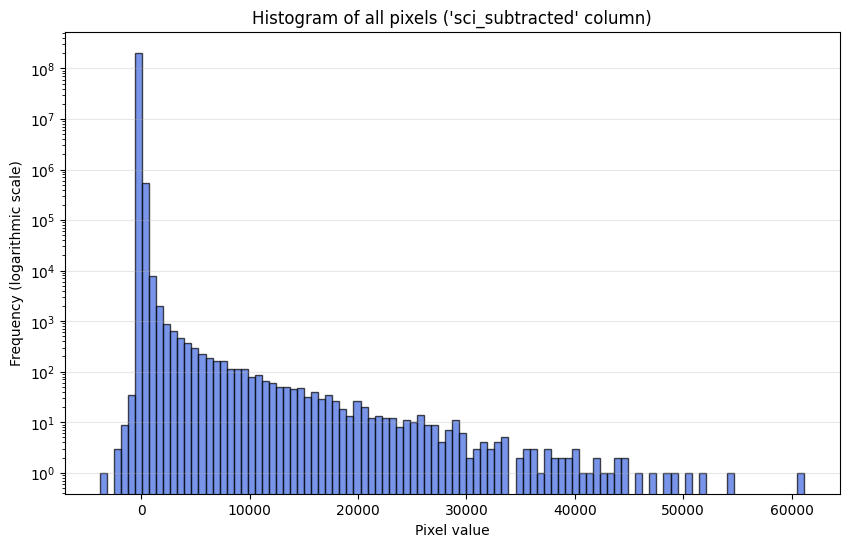

In [1]:
# 1. Install the Hugging Face Datasets library (if not already installed)
!pip install datasets -q

# 2. Import necessary modules
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt

# 3. Load the dataset (we load the 'train' split by default)
print("Loading dataset...")
dataset = load_dataset("VincentB03/Euclid-Q1-VF", split="train")

# 4. Extract the 'sci_subtracted' column
print("Extracting images...")
sci_subtracted_data = dataset['sci_subtracted']

# 5. Convert to a NumPy array and flatten
# np.array transforms the list of 64x64 images into a 3D array
# .flatten() transforms this array into a 1D vector containing absolutely all pixels
print("Processing pixels...")
all_pixels = np.array(sci_subtracted_data).flatten()

# 6. Plot the histogram
print("Creating the histogram...")
plt.figure(figsize=(10, 6))

# We use bins=100 (100 columns).
# log=True is highly recommended for astronomical images because the majority of the background
# is close to 0, with a few very bright pixels.
plt.hist(all_pixels, bins=100, color='royalblue', edgecolor='black', alpha=0.7, log=True)

plt.title("Histogram of all pixels ('sci_subtracted' column)")
plt.xlabel("Pixel value")
plt.ylabel("Frequency (logarithmic scale)")
plt.grid(axis='y', alpha=0.3)

# Display the plot
plt.show()

Loading dataset...
Extracting and flattening images...
Calculating percentiles on a subsample...
95th Percentile: 20207.66
99th Percentile: 40528.80
Creating the histogram...


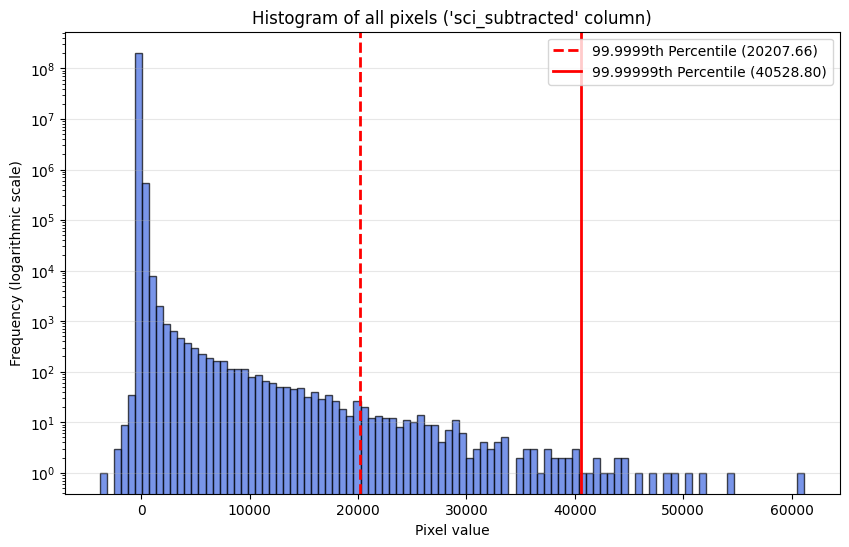

In [5]:
# 1. Install the Hugging Face Datasets library
!pip install datasets -q

# 2. Import necessary modules
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt

# 3. Load the dataset
print("Loading dataset...")
dataset = load_dataset("VincentB03/Euclid-Q1-VF", split="train")

# 4. Extract and flatten images
print("Extracting and flattening images...")
sci_subtracted_data = dataset['sci_subtracted']
all_pixels = np.array(sci_subtracted_data).flatten()

# 5. THE TRICK: Use a subsample (1 every 10 pixels) to save RAM during sorting
print("Calculating percentiles on a subsample...")
subsample = all_pixels[::10]
p99_9999 = np.percentile(subsample, 99.9999)
p99_99999 = np.percentile(subsample, 99.99999)

print(f"95th Percentile: {p99_9999:.2f}")
print(f"99th Percentile: {p99_99999:.2f}")

# 6. Plot the histogram using all pixels
print("Creating the histogram...")
plt.figure(figsize=(10, 6))

plt.hist(all_pixels, bins=100, color='royalblue', edgecolor='black', alpha=0.7, log=True)

# Add the vertical red lines
plt.axvline(p99_9999, color='red', linestyle='dashed', linewidth=2, label=f'99.9999th Percentile ({p99_9999:.2f})')
plt.axvline(p99_99999, color='red', linestyle='solid', linewidth=2, label=f'99.99999th Percentile ({p99_99999:.2f})')

plt.title("Histogram of all pixels ('sci_subtracted' column)")
plt.xlabel("Pixel value")
plt.ylabel("Frequency (logarithmic scale)")
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.show()